Shape: (45211, 17)
y
no     39922
yes     5289
Name: count, dtype: int64

y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Missing values in the whole dataset: 0


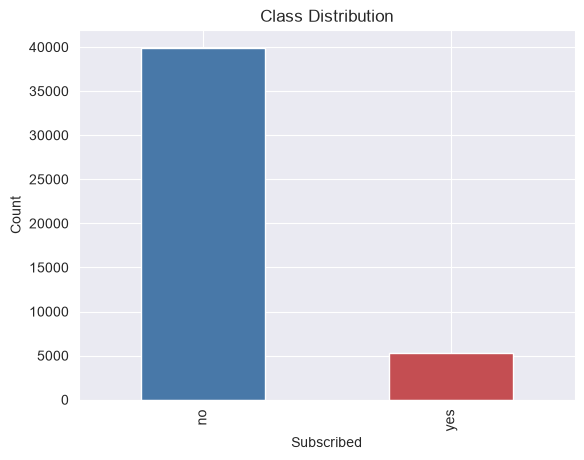

Features after one-hot encoding: 51
Train: (36168, 51)  Test: (9043, 51)

Class balance in the training set (still imbalanced at this point):
y
0    0.883
1    0.117
Name: proportion, dtype: float64
Best baseline decision tree: max_depth = 9

              precision    recall  f1-score   support

          no       0.93      0.96      0.94      7985
         yes       0.61      0.42      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



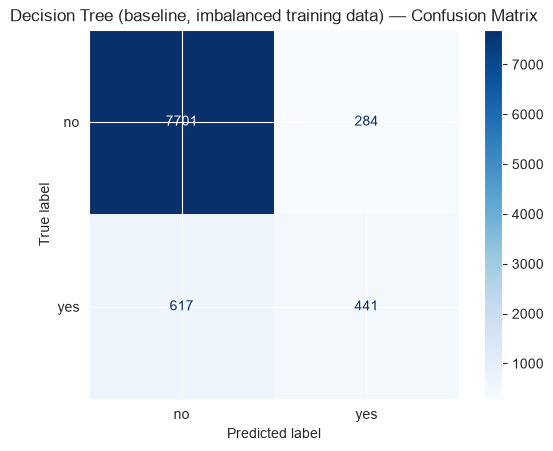

Best baseline neural network: hidden_layer_sizes = (32, 16)

              precision    recall  f1-score   support

          no       0.94      0.96      0.95      7985
         yes       0.61      0.50      0.55      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.73      0.75      9043
weighted avg       0.90      0.90      0.90      9043



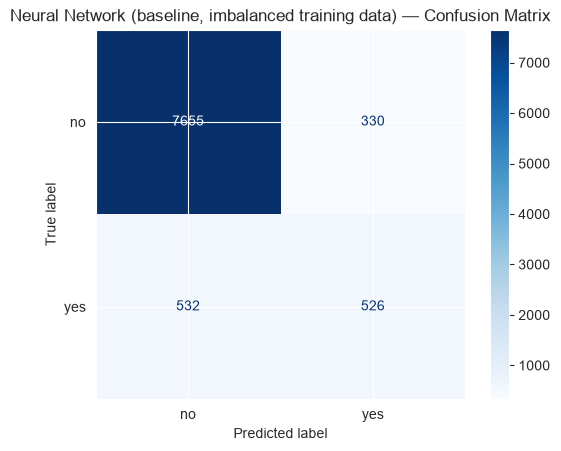

Both baseline models were trained directly on the imbalanced training set
(88% "no" / 12% "yes"). Accuracy looks strong, but check the Recall column —
that is the fraction of actual "yes" clients each model successfully identifies:
Balanced training set class counts:
y
1    31937
0    31937
Name: count, dtype: int64
Best decision tree (balanced training data): max_depth = 9

              precision    recall  f1-score   support

          no       0.98      0.81      0.89      7985
         yes       0.37      0.85      0.52      1058

    accuracy                           0.81      9043
   macro avg       0.67      0.83      0.70      9043
weighted avg       0.90      0.81      0.84      9043



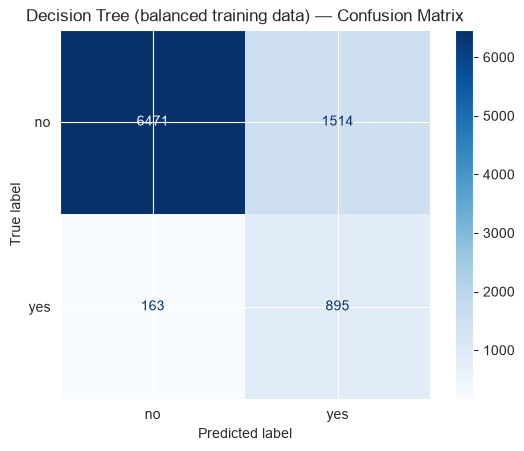

Best neural network (balanced training data): hidden_layer_sizes = (32, 16)

              precision    recall  f1-score   support

          no       0.97      0.86      0.91      7985
         yes       0.44      0.83      0.58      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.85      0.74      9043
weighted avg       0.91      0.86      0.87      9043



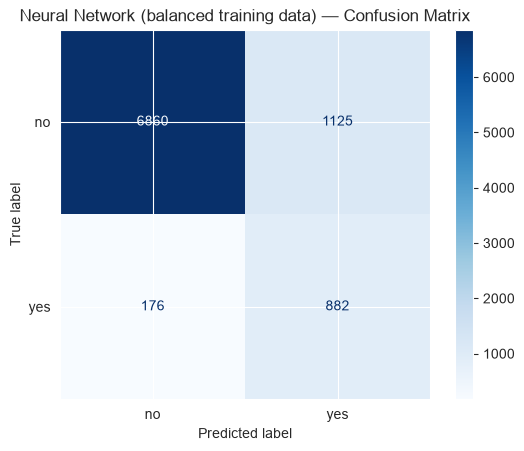

Baseline (imbalanced training data) vs balanced (oversampled training data):
                           Accuracy  Precision  Recall     F1  ROC-AUC
Decision Tree (baseline)      0.900      0.608   0.417  0.495    0.852
Decision Tree (balanced)      0.815      0.372   0.846  0.516    0.873
Neural Network (baseline)     0.905      0.614   0.497  0.550    0.923
Neural Network (balanced)     0.856      0.439   0.834  0.576    0.919

Recall on "yes" class:
  Decision Tree:   0.417 -> 0.846
  Neural Network:  0.497 -> 0.834


TypeError: RocCurveDisplay.from_estimator() got an unexpected keyword argument 'color'

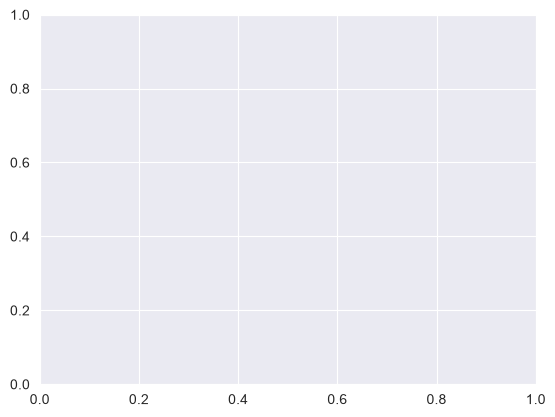

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42  # fixed seed so every run gives the same results

# --- Load the dataset ---
df = pd.read_csv('bank-full.csv', sep=';')
print('Shape:', df.shape)
df.head()

# --- EDA recap ---
print(df['y'].value_counts())
print()
print(df['y'].value_counts(normalize=True).round(3))
print()
print('Missing values in the whole dataset:', df.isna().sum().sum())

df['y'].value_counts().plot(kind='bar', title='Class Distribution', xlabel='Subscribed', ylabel='Count',
                             color=['#4878A8', '#C44E52'])
plt.show()

# --- Data preparation encode target, one hot encode, split, scale ---
# 1. target: yes -> 1, no -> 0
df['y'] = (df['y'] == 'yes').astype(int)

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# 2. one hot encode every categorical column
X = pd.get_dummies(df.drop(columns='y'))
y = df['y']
print('Features after one-hot encoding:', X.shape[1])

# 3. stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# 4. standardise numeric features (fit on train only)
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Train:', X_train.shape, ' Test:', X_test.shape)
print()
print('Class balance in the training set (still imbalanced at this point):')
print(y_train.value_counts(normalize=True).round(3))

# --- Evaluation ---
def evaluate(model):
    """Return a dict of test-set metrics for a fitted model."""
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {'Accuracy':  accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall':    recall_score(y_test, pred),
            'F1':        f1_score(y_test, pred),
            'ROC-AUC':   roc_auc_score(y_test, proba)}

# --- Baseline Decision Tree trained directly on the IMBALANCED training set ---
dt_base_models, dt_base_results = {}, {}

for depth in [3, 5, 7, 9, None]:          # None = grow the tree fully
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    dt_base_models[str(depth)] = model
    dt_base_results[str(depth)] = evaluate(model)

dt_base_results = pd.DataFrame(dt_base_results).T.round(3)
dt_base_results.index.name = 'max_depth'
dt_base_results

# --- Baseline Decision Tree best model evaluation ---
best_depth_base = dt_base_results['F1'].idxmax()
dt_base_best = dt_base_models[best_depth_base]
print('Best baseline decision tree: max_depth =', best_depth_base)
print()
print(classification_report(y_test, dt_base_best.predict(X_test), target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_estimator(dt_base_best, X_test, y_test, display_labels=['no', 'yes'], cmap='Blues')
plt.title('Decision Tree (baseline, imbalanced training data) — Confusion Matrix')
plt.show()

# --- Baseline Neural Network trained directly on the IMBALANCED training set ---
nn_base_models, nn_base_results = {}, {}

for hidden in [(16,), (32, 16), (64, 32)]:
    model = MLPClassifier(hidden_layer_sizes=hidden, max_iter=100,
                          early_stopping=True, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    nn_base_models[str(hidden)] = model
    nn_base_results[str(hidden)] = evaluate(model)

nn_base_results = pd.DataFrame(nn_base_results).T.round(3)
nn_base_results.index.name = 'hidden_layers'
nn_base_results

# --- Baseline Neural Network best model evaluation ---
best_hidden_base = nn_base_results['F1'].idxmax()
nn_base_best = nn_base_models[best_hidden_base]
print('Best baseline neural network: hidden_layer_sizes =', best_hidden_base)
print()
print(classification_report(y_test, nn_base_best.predict(X_test), target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_estimator(nn_base_best, X_test, y_test, display_labels=['no', 'yes'], cmap='Blues')
plt.title('Neural Network (baseline, imbalanced training data) — Confusion Matrix')
plt.show()

# --- Baseline summary: does class imbalance hurt recall on "yes"? ---
baseline_comparison = pd.DataFrame({'Decision Tree (baseline)': evaluate(dt_base_best),
                                    'Neural Network (baseline)': evaluate(nn_base_best)}).T.round(3)

print('Both baseline models were trained directly on the imbalanced training set')
print('(88% "no" / 12% "yes"). Accuracy looks strong, but check the Recall column —')
print('that is the fraction of actual "yes" clients each model successfully identifies:')
baseline_comparison

# --- Improvement technique: random oversampling of the minority class ---
# The baseline results above show weak recall on the "yes" class because the
# training data is imbalanced. We now rebalance the TRAINING set only (never
# the test set, so evaluation stays realistic) and re-run both models on it.
train = X_train.copy()
train['y'] = y_train

majority = train[train['y'] == 0]
minority = train[train['y'] == 1]
minority_up = resample(minority, replace=True, n_samples=len(majority),
                       random_state=RANDOM_STATE)

train_bal = pd.concat([majority, minority_up]).sample(frac=1, random_state=RANDOM_STATE)
X_train_bal = train_bal.drop(columns='y')
y_train_bal = train_bal['y']

print('Balanced training set class counts:')
print(y_train_bal.value_counts())

# --- Decision Tree retrained on the BALANCED training set ---
dt_bal_models, dt_bal_results = {}, {}

for depth in [3, 5, 7, 9, None]:          # None = grow the tree fully
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train_bal, y_train_bal)
    dt_bal_models[str(depth)] = model
    dt_bal_results[str(depth)] = evaluate(model)

dt_bal_results = pd.DataFrame(dt_bal_results).T.round(3)
dt_bal_results.index.name = 'max_depth'
dt_bal_results

# --- Decision Tree (balanced) best model evaluation ---
best_depth_bal = dt_bal_results['F1'].idxmax()
dt_bal_best = dt_bal_models[best_depth_bal]
print('Best decision tree (balanced training data): max_depth =', best_depth_bal)
print()
print(classification_report(y_test, dt_bal_best.predict(X_test), target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_estimator(dt_bal_best, X_test, y_test, display_labels=['no', 'yes'], cmap='Blues')
plt.title('Decision Tree (balanced training data) — Confusion Matrix')
plt.show()

# --- Neural Network retrained on the BALANCED training set ---
nn_bal_models, nn_bal_results = {}, {}

for hidden in [(16,), (32, 16), (64, 32)]:
    model = MLPClassifier(hidden_layer_sizes=hidden, max_iter=100,
                          early_stopping=True, random_state=RANDOM_STATE)
    model.fit(X_train_bal, y_train_bal)
    nn_bal_models[str(hidden)] = model
    nn_bal_results[str(hidden)] = evaluate(model)

nn_bal_results = pd.DataFrame(nn_bal_results).T.round(3)
nn_bal_results.index.name = 'hidden_layers'
nn_bal_results

# --- Neural Network (balanced) best model evaluation ---
best_hidden_bal = nn_bal_results['F1'].idxmax()
nn_bal_best = nn_bal_models[best_hidden_bal]
print('Best neural network (balanced training data): hidden_layer_sizes =', best_hidden_bal)
print()
print(classification_report(y_test, nn_bal_best.predict(X_test), target_names=['no', 'yes']))

ConfusionMatrixDisplay.from_estimator(nn_bal_best, X_test, y_test, display_labels=['no', 'yes'], cmap='Blues')
plt.title('Neural Network (balanced training data) — Confusion Matrix')
plt.show()

# --- seeing the effect of oversampling baseline vs balanced training ---
improvement_comparison = pd.DataFrame({
    'Decision Tree (baseline)':   evaluate(dt_base_best),
    'Decision Tree (balanced)':   evaluate(dt_bal_best),
    'Neural Network (baseline)':  evaluate(nn_base_best),
    'Neural Network (balanced)':  evaluate(nn_bal_best)
}).T.round(3)

print('Baseline (imbalanced training data) vs balanced (oversampled training data):')
print(improvement_comparison)
print()
print('Recall on "yes" class:')
print('  Decision Tree:   {:.3f} -> {:.3f}'.format(
    evaluate(dt_base_best)['Recall'], evaluate(dt_bal_best)['Recall']))
print('  Neural Network:  {:.3f} -> {:.3f}'.format(
    evaluate(nn_base_best)['Recall'], evaluate(nn_bal_best)['Recall']))

improvement_comparison

# --- Final comparison: Decision Tree vs Neural Network balanced training ---
final_comparison = pd.DataFrame({'Decision Tree': evaluate(dt_bal_best),
                                 'Neural Network': evaluate(nn_bal_best)}).T.round(3)

ax = plt.gca()
RocCurveDisplay.from_estimator(dt_bal_best, X_test, y_test, name='Decision Tree', ax=ax, color='#1F77B4')
RocCurveDisplay.from_estimator(nn_bal_best, X_test, y_test, name='Neural Network', ax=ax, color='#FF7F0E')
plt.title('ROC Curves — Decision Tree vs Neural Network (balanced training data)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
plt.show()

final_comparison